In [ ]:
!pip install fastf1

In [ ]:
import fastf1
import matplotlib.pyplot as plt
import os
import pandas as pd
import numpy as np


os.makedirs('/content/cache', exist_ok=True)


fastf1.Cache.enable_cache('/content/cache')

In [ ]:
session = fastf1.get_session(2023, 'Silverstone', 'Q')
session.load()

core           INFO 	Loading data for British Grand Prix - Qualifying [v3.8.2]
INFO:fastf1.fastf1.core:Loading data for British Grand Prix - Qualifying [v3.8.2]
req            INFO 	Using cached data for session_info
INFO:fastf1.fastf1.req:Using cached data for session_info
req            INFO 	Using cached data for driver_info
INFO:fastf1.fastf1.req:Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
INFO:fastf1.fastf1.req:Using cached data for session_status_data
req            INFO 	Using cached data for track_status_data
INFO:fastf1.fastf1.req:Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
INFO:fastf1.fastf1.req:Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
INFO:fastf1.fastf1.req:Using cached data for timing_app_data
core           INFO 	Processing timing data...
INFO:fastf1.fastf1.core:Processing timing data...
req         

In [ ]:
drivers = ['VER', 'HAM', 'LEC', 'NOR', 'SAI']

all_data = []

for drv in drivers:
    lap = session.laps.pick_driver(drv).pick_fastest()
    tel = lap.get_telemetry()

    df_temp = tel[['X', 'Y', 'Speed']].copy()

    # progress (0 → 1)
    df_temp['progress'] = np.linspace(0, 1, len(df_temp))

    all_data.append(df_temp)

# combine all drivers
df = pd.concat(all_data, ignore_index=True)

/usr/local/lib/python3.12/dist-packages/fastf1/core.py:3129: FutureWarning: pick_driver is deprecated and will be removed in a future release. Use pick_drivers instead.
  warnings.warn(("pick_driver is deprecated and will be removed"
/usr/local/lib/python3.12/dist-packages/fastf1/core.py:3129: FutureWarning: pick_driver is deprecated and will be removed in a future release. Use pick_drivers instead.
  warnings.warn(("pick_driver is deprecated and will be removed"
/usr/local/lib/python3.12/dist-packages/fastf1/core.py:3129: FutureWarning: pick_driver is deprecated and will be removed in a future release. Use pick_drivers instead.
  warnings.warn(("pick_driver is deprecated and will be removed"
/usr/local/lib/python3.12/dist-packages/fastf1/core.py:3129: FutureWarning: pick_driver is deprecated and will be removed in a future release. Use pick_drivers instead.
  warnings.warn(("pick_driver is deprecated and will be removed"
/usr/local/lib/python3.12/dist-packages/fastf1/core.py:3129: Fut

In [ ]:
x = df['X'].values
y = df['Y'].values
speed = df['Speed'].values

In [ ]:
import pandas as pd

speed_smooth = pd.Series(speed).rolling(window=10, center=True).mean()
speed_smooth = speed_smooth.fillna(method='bfill').fillna(method='ffill')

threshold = np.percentile(speed_smooth, 40)
low_speed_mask = speed_smooth < threshold

/tmp/ipykernel_3762/1621604494.py:4: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  speed_smooth = speed_smooth.fillna(method='bfill').fillna(method='ffill')


In [ ]:
from scipy.ndimage import label

labels, num_features = label(low_speed_mask)

In [ ]:
# apex_x = []
# apex_y = []

# for i in range(1, num_features + 1):
#     indices = np.where(labels == i)[0]

#     if len(indices) == 0:
#         continue

#     # minimum speed point = apex
#     min_idx = indices[np.argmin(speed[indices])]

#     apex_x.append(x[min_idx])
#     apex_y.append(y[min_idx])
apex_x = []
apex_y = []

for i in range(1, num_features + 1):
    indices = np.where(labels == i)[0]

    if len(indices) < 30:   # 🔥 ignore tiny segments
        continue

    min_idx = indices[np.argmin(speed[indices])]

    apex_x.append(x[min_idx])
    apex_y.append(y[min_idx])

In [ ]:
# corner awareness (slow = corner)
df['corner_strength'] = 1 - (df['Speed'] / df['Speed'].max())

# direction
df['dx'] = df['X'].diff()
df['dy'] = df['Y'].diff()

df['theta'] = np.arctan2(df['dy'], df['dx'])

# curvature
df['ddx'] = df['dx'].diff()
df['ddy'] = df['dy'].diff()

df['curvature'] = np.sqrt(df['ddx']**2 + df['ddy']**2)

# apex
df['is_apex'] = 0

for ax, ay in zip(apex_x, apex_y):
    dist = np.sqrt((df['X'] - ax)**2 + (df['Y'] - ay)**2)
    df.loc[dist < 50, 'is_apex'] = 1

# progress (VERY IMPORTANT)
distances = np.sqrt(np.diff(df['X'], prepend=df['X'][0])**2 +
                    np.diff(df['Y'], prepend=df['Y'][0])**2)

# dist = np.sqrt(df['dx']**2 + df['dy']**2)

df['progress'] = np.cumsum(distances)
df['progress'] = df['progress'] / df['progress'].max()

# clean
df = df.dropna().reset_index(drop=True)


In [ ]:
features = [
    'progress',
    'Speed',
    'corner_strength',
    # 'theta',
    # 'curvature',
    # 'dx',
    # 'dy',
    # 'is_apex'
]
# # features
# features = ['progress', 'Speed', 'corner_strength']
# target
# y_target = df[['X', 'Y']]
target = ['X', 'Y']
y_data = df[target].values

In [ ]:
from sklearn.ensemble import RandomForestRegressor

# model = RandomForestRegressor(n_estimators=200, random_state=42)
# model.fit(df[features], y_data)
rf_model = RandomForestRegressor(n_estimators=200, random_state=42)
rf_model.fit(df[features], y_data)

RandomForestRegressor(n_estimators=200, random_state=42)

In [ ]:
# # fix dataframe
# df = df.sort_values('progress').reset_index(drop=True)
# df = df.drop_duplicates(subset='progress')
# # smooth progress
# progress_vals = np.linspace(0, 1, 500)

# # interpolate from real data
# speed_vals = np.interp(progress_vals, df['progress'], df['Speed'])
# # theta_vals = np.zeros_like(progress_vals)
# curvature_vals = np.zeros_like(progress_vals)
# # apex_vals = np.interp(progress_vals, df['progress'], df['is_apex'])
# apex_vals = np.interp(progress_vals, df['progress'], df['is_apex'])
# apex_vals = (apex_vals > 0.5).astype(int)

# # recompute corner strength
# corner_vals = 1 - (speed_vals / df['Speed'].max())

# # build DataFrame (IMPORTANT)
# X_input_df = pd.DataFrame({
#     'progress': progress_vals,
#     'Speed': speed_vals,
#     'corner_strength': corner_vals,
#     # 'theta': theta_vals,
#     # 'curvature': curvature_vals,
#     'is_apex': apex_vals
# })

# # predict
# predicted_path = rf_model.predict(X_input_df)


In [ ]:
# ================================
# FIX DATAFRAME
# ================================
df = df.sort_values('progress').reset_index(drop=True)
df = df.drop_duplicates(subset='progress')

# ================================
# SMOOTH PROGRESS
# ================================
progress_vals = np.linspace(0, 1, 500)

# ================================
# INTERPOLATE FEATURES
# ================================
speed_vals = np.interp(progress_vals, df['progress'], df['Speed'])

# recompute corner strength
corner_vals = 1 - (speed_vals / df['Speed'].max())

# ================================
# BUILD INPUT (MATCH TRAINING FEATURES)
# ================================
X_input_df = pd.DataFrame({
    'progress': progress_vals,
    'Speed': speed_vals,
    'corner_strength': corner_vals
})

# ================================
# PREDICT
# ================================
predicted_path = rf_model.predict(X_input_df)

In [ ]:
# # smooth progress
# progress_vals = np.linspace(0, 1, 500)

# # interpolate speed from real data
# speed_vals = np.interp(progress_vals, df['progress'], df['Speed'])

# # recompute corner strength
# corner_vals = 1 - (speed_vals / df['Speed'].max())

# # build input
# X_input = np.column_stack([progress_vals, speed_vals, corner_vals])

# # predict
# predicted_path = model.predict(X_input)

/usr/local/lib/python3.12/dist-packages/fastf1/core.py:3129: FutureWarning: pick_driver is deprecated and will be removed in a future release. Use pick_drivers instead.
  warnings.warn(("pick_driver is deprecated and will be removed"


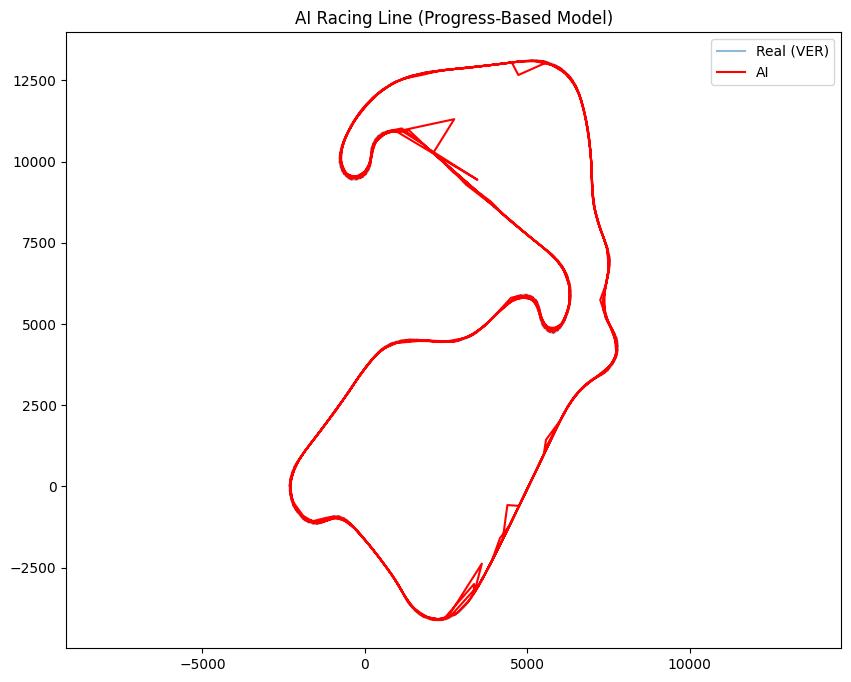

In [ ]:
plt.figure(figsize=(10,8))

# real line (one driver for reference)
ref_lap = session.laps.pick_driver('VER').pick_fastest()
ref_tel = ref_lap.get_telemetry()

plt.plot(ref_tel['X'], ref_tel['Y'], label='Real (VER)', alpha=0.5)

# AI line
plt.plot(predicted_path[:,0], predicted_path[:,1], label='AI', color='red')

plt.legend()
plt.axis('equal')
plt.title("AI Racing Line (Progress-Based Model)")
plt.show()

In [ ]:
rf_model.fit(df[features], y_data)

RandomForestRegressor(n_estimators=200, random_state=42)

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

y_pred = rf_model.predict(df[features])   # ✅ FIXED

rmse = np.sqrt(mean_squared_error(y_data, y_pred))
mae = mean_absolute_error(y_data, y_pred)
r2 = r2_score(y_data, y_pred)

print("RMSE:", rmse)
print("MAE:", mae)
print("R2:", r2)

RMSE: 45.53060522432215
MAE: 14.912807796309504
R2: 0.9998753986986462


In [ ]:
dist_error = np.sqrt(
    (y_pred[:,0] - y_data[:,0])**2 +
    (y_pred[:,1] - y_data[:,1])**2
)

print("Mean Track Error:", np.mean(dist_error))

Mean Track Error: 23.10627540182912


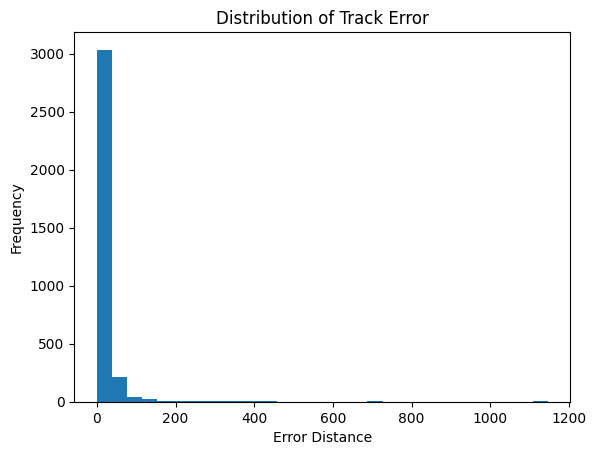

In [ ]:
dist_error = np.sqrt(
    (y_pred[:,0] - y_data[:,0])**2 +
    (y_pred[:,1] - y_data[:,1])**2
)

plt.figure()
plt.hist(dist_error, bins=30)

plt.title("Distribution of Track Error")
plt.xlabel("Error Distance")
plt.ylabel("Frequency")
plt.show()

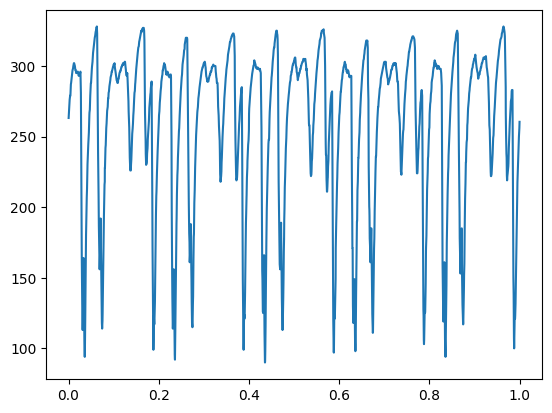

In [ ]:
plt.plot(df['progress'], df['Speed'])

now marks the start of LSTM

In [ ]:
# import numpy as np
# import pandas as pd

# -------------------------------
# 1. BASIC COPY
# -------------------------------
df = tel[['X', 'Y', 'Speed']].copy()

# -------------------------------
# 2. MOTION (VERY IMPORTANT)
# -------------------------------
df['dx'] = df['X'].diff().fillna(0)
df['dy'] = df['Y'].diff().fillna(0)

# -------------------------------
# 3. PROGRESS (SMOOTH TRACK POSITION)
# -------------------------------
distances = np.sqrt(df['dx']**2 + df['dy']**2)
df['progress'] = np.cumsum(distances)
df['progress'] = df['progress'] / df['progress'].max()

# -------------------------------
# 4. SPEED SMOOTHING (optional but good)
# -------------------------------
df['Speed'] = df['Speed'].rolling(window=5, center=True).mean()
df['Speed'] = df['Speed'].bfill().ffill()

# -------------------------------
# 5. CORNER STRENGTH (SLOW = CORNER)
# -------------------------------
df['corner_strength'] = 1 - (df['Speed'] / df['Speed'].max())
# 6. curvature
df['ddx'] = df['dx'].diff().fillna(0)
df['ddy'] = df['dy'].diff().fillna(0)

df['curvature'] = np.sqrt(df['ddx']**2 + df['ddy']**2)
df['curvature'] = df['curvature'] / df['curvature'].max()

# -------------------------------
# 6. FINAL FEATURES (KEEP THIS SIMPLE)
# -------------------------------
features = [
    'progress',
    'Speed',
    'corner_strength',
    'dx',
    'dy',
    'curvature'
]

# -------------------------------
# 7. TARGET (NEXT POSITION)
# -------------------------------
df['dx_next'] = df['dx'].shift(-1)
df['dy_next'] = df['dy'].shift(-1)

df = df.dropna().reset_index(drop=True)

y_target = df[['dx_next', 'dy_next']]

# -------------------------------
# 8. FINAL CHECK
# -------------------------------
print("Features:", features)
print("X shape:", df[features].shape)
print("y shape:", y_target.shape)

Features: ['progress', 'Speed', 'corner_strength', 'dx', 'dy', 'curvature']
X shape: (670, 6)
y shape: (670, 2)


In [ ]:
# import numpy as np

# sequence length (IMPORTANT hyperparameter)
sequence_length = 40

X_data = df[features].values
y_data = df[target].values

X_seq = []
y_seq = []

for i in range(len(df) - sequence_length):
    X_seq.append(X_data[i:i+sequence_length])
    y_seq.append(y_data[i+sequence_length])

X_seq = np.array(X_seq)
y_seq = np.array(y_seq)

print("X_seq shape:", X_seq.shape)
print("y_seq shape:", y_seq.shape)

X_seq shape: (630, 40, 6)
y_seq shape: (630, 2)


In [ ]:
from sklearn.preprocessing import MinMaxScaler

# scalers
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

# reshape for scaling
X_seq_reshaped = X_seq.reshape(-1, X_seq.shape[2])

# scale X
X_scaled = scaler_X.fit_transform(X_seq_reshaped)
X_scaled = X_scaled.reshape(X_seq.shape)

# scale y
y_scaled = scaler_y.fit_transform(y_seq)

print("X_scaled shape:", X_scaled.shape)
print("y_scaled shape:", y_scaled.shape)

X_scaled shape: (630, 40, 6)
y_scaled shape: (630, 2)


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_scaled,
    test_size=0.2,
    random_state=42
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (504, 40, 6)
Test shape: (126, 40, 6)


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Input

model = Sequential([
    Input(shape=(X_train.shape[1], X_train.shape[2])),

    LSTM(64, return_sequences=False),

    Dense(32, activation='relu'),

    Dense(2)   # output (X, Y)
])

model.compile(
    optimizer='adam',
    loss='mse'
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        18,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │            66 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,322 (79.38 KB)

 Trainable params: 20,322 (79.38 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(
    X_train, y_train,
    epochs=40,
    batch_size=16,
    validation_data=(X_test, y_test)
)

Epoch 1/40
32/32 ━━━━━━━━━━━━━━━━━━━━ 6s 62ms/step - loss: 0.1231 - val_loss: 0.0640
Epoch 2/40
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 63ms/step - loss: 0.0512 - val_loss: 0.0379
Epoch 3/40
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - loss: 0.0321 - val_loss: 0.0235
Epoch 4/40
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - loss: 0.0192 - val_loss: 0.0157
Epoch 5/40
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - loss: 0.0105 - val_loss: 0.0101
Epoch 6/40
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - loss: 0.0070 - val_loss: 0.0037
Epoch 7/40
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - loss: 0.0037 - val_loss: 0.0024
Epoch 8/40
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step - loss: 0.0022 - val_loss: 0.0029
Epoch 9/40
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 47ms/step - loss: 0.0022 - val_loss: 0.0017
Epoch 10/40
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - loss: 0.0014 - val_loss: 0.0016
Epoch 11/40
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 0.0012 - val_loss: 9.8063e-04
Epoch 12/40
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss:

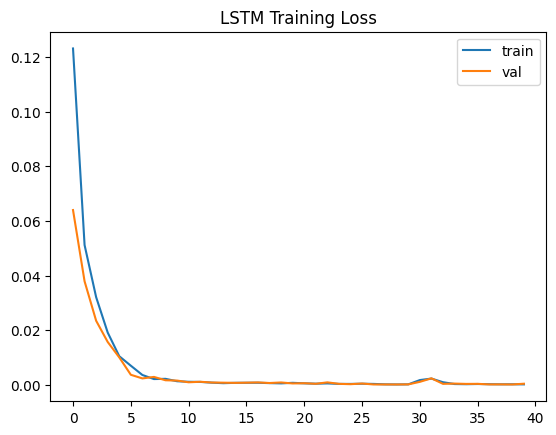

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')

plt.legend()
plt.title("LSTM Training Loss")
plt.show()

In [ ]:
# import matplotlib.pyplot as plt

# # -------------------------------
# # START SEQUENCE (SCALED!)
# # -------------------------------
# current_seq = X_scaled[0].copy()

# predicted_path = []

# # starting point
# x_curr, y_curr = df[['X', 'Y']].iloc[0]

# # -------------------------------
# # GENERATE PATH
# # -------------------------------
# for step in range(len(df)):

#     # predict (scaled → unscaled)
#     pred = model.predict(current_seq.reshape(1, 20, -1), verbose=0)
#     pred_unscaled = scaler_y.inverse_transform(pred)

#     x_next, y_next = pred_unscaled[0]

#     # -------------------------------
#     # BLENDING (stability)
#     # -------------------------------
#     alpha = 0.85

#     real_idx = min(step, len(df)-1)
#     x_real = df['X'].iloc[real_idx]
#     y_real = df['Y'].iloc[real_idx]

#     x_next = alpha * x_real + (1 - alpha) * x_next
#     y_next = alpha * y_real + (1 - alpha) * y_next

#     # -------------------------------
#     # MOTION
#     # -------------------------------
#     dx = x_next - x_curr
#     dy = y_next - y_curr

#     # limit jumps
#     max_step = 60
#     dx = np.clip(dx, -max_step, max_step)
#     dy = np.clip(dy, -max_step, max_step)

#     # update position
#     x_curr += dx
#     y_curr += dy

#     predicted_path.append([x_curr, y_curr])

#     # -------------------------------
#     # FEATURES
#     # -------------------------------
#     nearest_idx = np.argmin((df['X'] - x_curr)**2 + (df['Y'] - y_curr)**2)

#     progress = df['progress'].iloc[nearest_idx]

#     progress = dist / df['progress'].max()
#     progress = np.clip(progress, 0, 1)

#     speed_val = np.interp(progress, df['progress'], df['Speed'])
#     corner_strength = 1 - (speed_val / df['Speed'].max())
#     curvature = np.interp(progress, df['progress'], df['curvature'])

#     # -------------------------------
#     # BUILD NEXT INPUT (SCALED)
#     # -------------------------------
#     new_input = np.array([[
#         progress,
#         speed_val,
#         corner_strength,
#         dx,
#         dy,
#         curvature
#     ]])

#     new_input_scaled = scaler_X.transform(new_input)[0]

#     current_seq = np.vstack([current_seq[1:], new_input_scaled])

# # -------------------------------
# # SMOOTH PATH
# # -------------------------------
# predicted_path = np.array(predicted_path)

# predicted_path = pd.DataFrame(predicted_path)
# predicted_path = predicted_path.rolling(10, center=True).mean().bfill().ffill()
# predicted_path = predicted_path.values

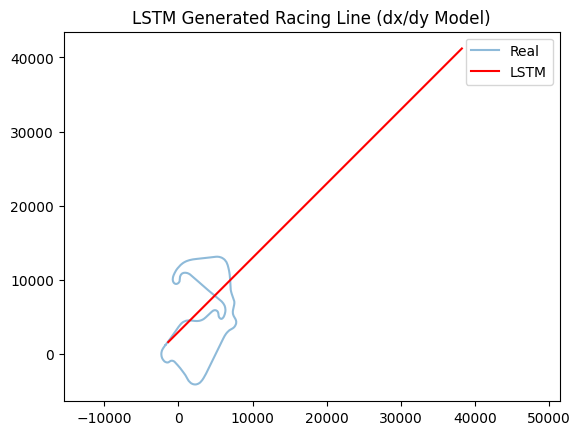

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# -------------------------------
# START SEQUENCE (SCALED!)
# -------------------------------
current_seq = X_scaled[0].copy()

predicted_path = []

# starting point
x_curr, y_curr = df[['X', 'Y']].iloc[0]

# -------------------------------
# GENERATE PATH
# -------------------------------
for step in range(len(df)):

    # predict (dx, dy)
    pred = model.predict(current_seq.reshape(1, 40, -1), verbose=0)
    pred_unscaled = scaler_y.inverse_transform(pred)

    dx_pred, dy_pred = pred_unscaled[0]

    # -------------------------------
    # BLENDING (FIXED)
    # -------------------------------
    alpha = 0.85

    real_idx = min(step, len(df)-1)

    dx_real = df['dx'].iloc[real_idx]
    dy_real = df['dy'].iloc[real_idx]

    dx = alpha * dx_real + (1 - alpha) * dx_pred
    dy = alpha * dy_real + (1 - alpha) * dy_pred

    # -------------------------------
    # LIMIT MOTION
    # -------------------------------
    max_step = 60
    dx = np.clip(dx, -max_step, max_step)
    dy = np.clip(dy, -max_step, max_step)

    # -------------------------------
    # UPDATE POSITION (IMPORTANT)
    # -------------------------------
    x_curr += dx
    y_curr += dy

    predicted_path.append([x_curr, y_curr])

    # -------------------------------
    # FEATURES
    # -------------------------------
    nearest_idx = np.argmin(
        (df['X'] - x_curr)**2 + (df['Y'] - y_curr)**2
    )

    progress = float(df['progress'].iloc[nearest_idx])

    speed_val = float(np.interp(progress, df['progress'], df['Speed']))
    corner_strength = float(1 - (speed_val / df['Speed'].max()))
    curvature = float(np.interp(progress, df['progress'], df['curvature']))

    dx = float(dx)
    dy = float(dy)

    # -------------------------------
    # BUILD INPUT (SCALED)
    # -------------------------------
    new_input = np.array([[
        progress,
        speed_val,
        corner_strength,
        dx,
        dy,
        curvature
    ]])

    new_input_scaled = scaler_X.transform(new_input)[0]

    current_seq = np.vstack([current_seq[1:], new_input_scaled])


# -------------------------------
# SMOOTH PATH
# -------------------------------
predicted_path = np.array(predicted_path)

predicted_path = pd.DataFrame(predicted_path)
predicted_path = predicted_path.rolling(10, center=True).mean().bfill().ffill()
predicted_path = predicted_path.values


# -------------------------------
# PLOT
# -------------------------------
plt.plot(df['X'], df['Y'], label='Real', alpha=0.5)
plt.plot(predicted_path[:,0], predicted_path[:,1], label='LSTM', color='red')

plt.legend()
plt.axis('equal')
plt.title("LSTM Generated Racing Line (dx/dy Model)")
plt.show()

new lstm latest

In [ ]:
import numpy as np
import pandas as pd

df = tel[['X', 'Y', 'Speed']].copy()

# MOTION

df['dx'] = df['X'].diff().fillna(0)
df['dy'] = df['Y'].diff().fillna(0)


# PROGRESS (track position)

distances = np.sqrt(df['dx']**2 + df['dy']**2)
df['progress'] = np.cumsum(distances)
df['progress'] = df['progress'] / df['progress'].max()
df['progress_sin'] = np.sin(2 * np.pi * df['progress'])
df['progress_cos'] = np.cos(2 * np.pi * df['progress'])

# SPEED SMOOTHING

df['Speed'] = df['Speed'].rolling(5, center=True).mean()
df['Speed'] = df['Speed'].bfill().ffill()

# -------------------------------
# CORNER + CURVATURE
# -------------------------------
df['corner_strength'] = 1 - (df['Speed'] / df['Speed'].max())

# curvature (important upgrade)
df['ddx'] = df['dx'].diff().fillna(0)
df['ddy'] = df['dy'].diff().fillna(0)
df['curvature'] = np.sqrt(df['ddx']**2 + df['ddy']**2)

df['distance_from_center'] = np.sqrt(df['X']**2 + df['Y']**2)

# -------------------------------
# FEATURES
# -------------------------------
features = [
    'progress_sin',
    'progress_cos',
    'Speed',
    'corner_strength',
    'dx',
    'dy',
    'curvature',
    'distance_from_center'
]

# -------------------------------
# TARGET = dx, dy (VERY IMPORTANT)
# -------------------------------
df['dx_next'] = df['dx'].shift(-1)
df['dy_next'] = df['dy'].shift(-1)

df = df.dropna().reset_index(drop=True)

y_target = df[['dx_next', 'dy_next']]

print("Features:", features)
print("X shape:", df[features].shape)
print("y shape:", y_target.shape)

Features: ['progress_sin', 'progress_cos', 'Speed', 'corner_strength', 'dx', 'dy', 'curvature', 'distance_from_center']
X shape: (670, 8)
y shape: (670, 2)


In [ ]:
sequence_length = 40

X_data = df[features].values
y_data = y_target.values

X_seq = []
y_seq = []

for i in range(len(df) - sequence_length):
    X_seq.append(X_data[i:i+sequence_length])
    y_seq.append(y_data[i+sequence_length])

X_seq = np.array(X_seq)
y_seq = np.array(y_seq)

print("X_seq:", X_seq.shape)
print("y_seq:", y_seq.shape)

X_seq: (630, 40, 8)
y_seq: (630, 2)


In [ ]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

# reshape for scaling
X_seq_reshaped = X_seq.reshape(-1, X_seq.shape[2])
X_scaled = scaler_X.fit_transform(X_seq_reshaped)
X_scaled = X_scaled.reshape(X_seq.shape)

y_scaled = scaler_y.fit_transform(y_seq)

# split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_scaled,
    test_size=0.2,
    random_state=42
)

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Input

model = Sequential([
    Input(shape=(X_train.shape[1], X_train.shape[2])),

    LSTM(64),
    Dense(32, activation='relu'),

    Dense(2)  # dx, dy
])

model.compile(optimizer='adam', loss='mse')

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 64)             │        18,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 2)              │            66 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,834 (81.38 KB)

 Trainable params: 20,834 (81.38 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(
    X_train, y_train,
    epochs=40,
    batch_size=16,
    validation_data=(X_test, y_test)
)

Epoch 1/40
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 41ms/step - loss: 0.0445 - val_loss: 0.0133
Epoch 2/40
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - loss: 0.0101 - val_loss: 0.0115
Epoch 3/40
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0089 - val_loss: 0.0111
Epoch 4/40
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0082 - val_loss: 0.0100
Epoch 5/40
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0075 - val_loss: 0.0096
Epoch 6/40
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0074 - val_loss: 0.0091
Epoch 7/40
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.0069 - val_loss: 0.0092
Epoch 8/40
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0069 - val_loss: 0.0102
Epoch 9/40
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0073 - val_loss: 0.0092
Epoch 10/40
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0069 - val_loss: 0.0089
Epoch 11/40
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0069 - val_loss: 0.0087
Epoch 12/40
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 0.0

In [ ]:
import matplotlib.pyplot as plt

current_seq = X_scaled[0].copy()

predicted_path = []

# starting point
x_curr, y_curr = df[['X', 'Y']].iloc[0]

for step in range(len(df)*2):

    # -------------------------------
    # PREDICT dx, dy
    # -------------------------------
    pred = model.predict(current_seq.reshape(1, 40, -1), verbose=0)
    pred_unscaled = scaler_y.inverse_transform(pred)

    dx_pred, dy_pred = pred_unscaled[0]

    # -------------------------------
    # BLENDING (reduce over time)
    # -------------------------------
    alpha = max(0.5 - step * 0.0007, 0.1)

    real_idx = min(step, len(df)-1)
    x_real = df['X'].iloc[real_idx]
    y_real = df['Y'].iloc[real_idx]

    dx_real = x_real - x_curr
    dy_real = y_real - y_curr

    dx = alpha * dx_real + (1 - alpha) * dx_pred
    dy = alpha * dy_real + (1 - alpha) * dy_pred

    # -------------------------------
    # LIMIT MOVEMENT
    # -------------------------------
    max_step = 30
    dx = np.clip(dx, -max_step, max_step)
    dy = np.clip(dy, -max_step, max_step)

    # update position
    x_curr += dx
    y_curr += dy

    # -------------------------------
    # TRACK CORRECTION (CRITICAL)
    # -------------------------------
    nearest_idx = np.argmin(
        (df['X'] - x_curr)**2 + (df['Y'] - y_curr)**2
    )

    x_track = df['X'].iloc[nearest_idx]
    y_track = df['Y'].iloc[nearest_idx]

    beta = 0.1
    x_curr = (1 - beta) * x_curr + beta * x_track
    y_curr = (1 - beta) * y_curr + beta * y_track

    predicted_path.append([x_curr, y_curr])

    # -------------------------------
    # FEATURES (consistent)
    # -------------------------------
    progress = float(df['progress'].iloc[nearest_idx])

    progress_sin = np.sin(2 * np.pi * progress)
    progress_cos = np.cos(2 * np.pi * progress)

    speed_val = float(np.interp(progress, df['progress'], df['Speed']))
    corner_strength = float(1 - (speed_val / df['Speed'].max()))
    curvature = float(np.interp(progress, df['progress'], df['curvature']))
    distance_from_center = float(np.sqrt(x_curr**2 + y_curr**2))

    # -------------------------------
    # BUILD INPUT
    # -------------------------------
    new_input = np.array([[
        progress_sin,
        progress_cos,
        speed_val,
        corner_strength,
        dx,
        dy,
        curvature,
        distance_from_center
    ]])

    new_input_scaled = scaler_X.transform(new_input)[0]

    current_seq = np.vstack([current_seq[1:], new_input_scaled])

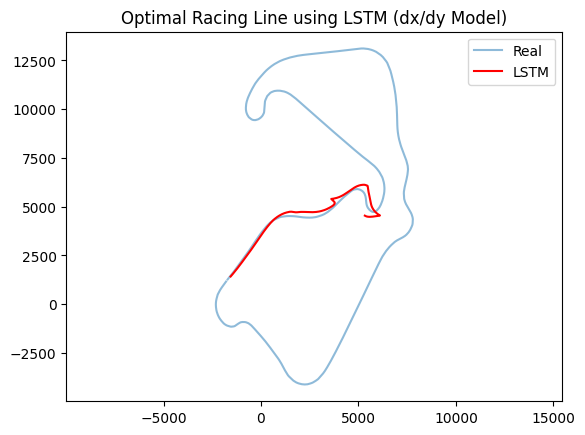

In [ ]:
predicted_path = np.array(predicted_path)

# smoothing
predicted_path = pd.DataFrame(predicted_path)
predicted_path = predicted_path.rolling(10, center=True).mean().bfill().ffill()
predicted_path = predicted_path.values

# plot
plt.plot(df['X'], df['Y'], label='Real', alpha=0.5)
plt.plot(predicted_path[:,0], predicted_path[:,1], label='LSTM', color='red')

plt.legend()
plt.axis('equal')
plt.title("Optimal Racing Line using LSTM (dx/dy Model)")
plt.show()

RL start

In [ ]:
# import numpy as np

# class RacingEnv:
#     def __init__(self, df):
#         self.df = df.reset_index(drop=True)
#         self.track = df[['X', 'Y']].values

#         self.reset()

#     def reset(self):
#         self.idx = 0
#         self.x, self.y = self.track[0]

#         # velocity (NEW)
#         self.dx = 0
#         self.dy = 0

#         self.prev_progress = 0
#         self.done = False

#         return self._get_state()

#     def _get_state(self):
#         # nearest track point
#         dists = np.sum((self.track - np.array([self.x, self.y]))**2, axis=1)
#         nearest_idx = np.argmin(dists)

#         progress = self.df['progress'].iloc[nearest_idx]

#         return np.array([
#             self.x,
#             self.y,
#             self.dx,     # NEW
#             self.dy,     # NEW
#             progress
#         ], dtype=np.float32)

#     def step(self, action):
#         dx_action, dy_action = action

#         # apply action
#         self.dx = dx_action
#         self.dy = dy_action

#         self.x += self.dx
#         self.y += self.dy

#         # -------------------------------
#         # COMPUTE DISTANCE TO TRACK
#         # -------------------------------
#         dists = np.sum((self.track - np.array([self.x, self.y]))**2, axis=1)
#         nearest_idx = np.argmin(dists)
#         dist_to_track = np.sqrt(dists[nearest_idx])

#         # progress
#         progress = self.df['progress'].iloc[nearest_idx]

#         # -------------------------------
#         # REWARD (IMPROVED)
#         # -------------------------------
#         reward = 0

#         # 1. stay close to track
#         reward -= dist_to_track * 0.02

#         # 2. forward progress (IMPORTANT)
#         delta_progress = progress - self.prev_progress
#         reward += delta_progress * 50

#         self.prev_progress = progress

#         # 3. smooth movement (penalize jerk)
#         reward -= (abs(self.dx) + abs(self.dy)) * 0.01

#         # -------------------------------
#         # TERMINATION
#         # -------------------------------

#         # off track
#         if dist_to_track > 100:
#             reward -= 20
#             self.done = True

#         # finish lap
#         if progress > 0.99:
#             reward += 100
#             self.done = True

#         return self._get_state(), reward, self.done, {}

In [ ]:
# import numpy as np

# class RacingEnv:
#     def __init__(self, df):
#         self.df = df.reset_index(drop=True)
#         self.track = df[['X', 'Y']].values

#         self.reset()

#     def reset(self):
#     # 🔥 RANDOM START
#       idx = np.random.randint(0, len(self.track))

#       self.x, self.y = self.track[idx]

#       # velocity
#       self.dx = 0
#       self.dy = 0

#       # 🔥 CRITICAL: correct progress initialization
#       self.prev_progress = self.df['progress'].iloc[idx]

#       self.done = False

#       return self._get_state()

#     def _get_state(self):
#         dists = np.sum((self.track - np.array([self.x, self.y]))**2, axis=1)
#         nearest_idx = np.argmin(dists)

#         progress = self.df['progress'].iloc[nearest_idx]

#         return np.array([
#             self.x,
#             self.y,
#             self.dx,
#             self.dy,
#             progress
#         ], dtype=np.float32)

#     def step(self, action):
#         dx_action, dy_action = action

#         # -------------------------------
#         # APPLY ACTION
#         # -------------------------------
#         self.dx = dx_action
#         self.dy = dy_action

#         self.x += self.dx
#         self.y += self.dy

#         # -------------------------------
#         # TRACK DISTANCE
#         # -------------------------------
#         dists = np.sum((self.track - np.array([self.x, self.y]))**2, axis=1)
#         nearest_idx = np.argmin(dists)
#         dist_to_track = np.sqrt(dists[nearest_idx])

#         progress = self.df['progress'].iloc[nearest_idx]

#         # -------------------------------
#         # REWARD (FIXED VERSION)
#         # -------------------------------
#         reward = 0

#         # 1. Stay close to track
#         reward -= dist_to_track * 0.02

#         # 2. STRONG forward progress
#         delta_progress = progress - self.prev_progress
#         reward += delta_progress * 200   # 🔥 increased

#         # 3. Penalize no movement / going backward
#         if delta_progress < 0.001:
#             reward -= 2

#         # 4. Smooth movement
#         reward -= (abs(self.dx) + abs(self.dy)) * 0.01

#         # 5. Small step penalty (prevents standing still)
#         reward -= 0.1

#         self.prev_progress = progress

#         # -------------------------------
#         # TERMINATION
#         # -------------------------------

#         # off track
#         if dist_to_track > 100:
#             reward -= 50
#             self.done = True

#         # finish lap
#         if progress > 0.99:
#             reward += 1000   # 🔥 BIG reward
#             self.done = True

#         return self._get_state(), reward, self.done, {}

In [ ]:
# import numpy as np

# class RacingEnv:
#     def __init__(self, df):
#         self.df = df.reset_index(drop=True)
#         self.track = df[['X', 'Y']].values

#         self.reset()

#     def reset(self):
#         # 🔥 RANDOM START
#         self.idx = np.random.randint(0, len(self.track))

#         self.x, self.y = self.track[self.idx]

#         # velocity
#         self.dx = 0
#         self.dy = 0

#         # progress tracking
#         self.prev_idx = self.idx

#         self.done = False

#         return self._get_state()

#     def _get_state(self):
#         nearest_idx = np.argmin(dists)
#         next_idx = min(nearest_idx + 5, len(self.track)-1)

#         dx_track = self.track[next_idx][0] - self.x
#         dy_track = self.track[next_idx][1] - self.y
#         progress = self.df['progress'].iloc[self.idx]

#         return np.array([
#             self.x,
#             self.y,
#             self.dx,
#             self.dy,
#             dx_track,
#             dy_track,
#             progress
#         ], dtype=np.float32)

#     def step(self, action):
#         dx_action, dy_action = action

#         # -------------------------------
#         # APPLY ACTION
#         # -------------------------------
#         self.dx = dx_action
#         self.dy = dy_action

#         self.x += self.dx
#         self.y += self.dy

#         # -------------------------------
#         # TARGET NEXT POINT (IMPORTANT)
#         # -------------------------------
#         target_x, target_y = self.track[self.idx]

#         dist_to_target = np.sqrt((self.x - target_x)**2 + (self.y - target_y)**2)

#         # 🔥 MOVE FORWARD ONLY IF CLOSE
#         if dist_to_target < 150:
#             self.idx += 1

#         # clamp
#         self.idx = min(self.idx, len(self.track) - 1)

#         progress = self.df['progress'].iloc[self.idx]

#         # -------------------------------
#         # DISTANCE FROM TRACK (for penalty)
#         # -------------------------------
#         dists = np.sum((self.track - np.array([self.x, self.y]))**2, axis=1)
#         dist_to_track = np.sqrt(np.min(dists))

#         # -------------------------------
#         # REWARD (CORRECTED)
#         # -------------------------------
#         reward = 0
#         reward += 0.5

#         # 1. stay close to track
#         reward -= dist_to_track * 0.01   # reduced penalty

#         # 2. forward movement
#         delta_idx = self.idx - self.prev_idx
#         reward += delta_idx * 50       # strong forward reward

#         # 3. discourage standing still
#         if delta_idx == 0:
#             reward -= 1

#         # 4. smooth movement
#         reward -= (abs(self.dx) + abs(self.dy)) * 0.005

#         self.prev_idx = self.idx

#         # -------------------------------
#         # TERMINATION
#         # -------------------------------
#         if dist_to_track > 300:
#             reward -= 20
#             self.done = True

#         if self.idx >= len(self.track) - 1:
#             reward += 1000
#             self.done = True

#         return self._get_state(), reward, self.done, {}

In [ ]:
import numpy as np

class RacingEnv:
    def __init__(self, df):
        self.df = df.reset_index(drop=True)
        self.track = df[['X', 'Y']].values

        self.reset()

    def reset(self):
        # RANDOM START
        self.idx = np.random.randint(0, len(self.track))

        self.x, self.y = self.track[self.idx]

        self.dx = 0
        self.dy = 0

        self.prev_idx = self.idx
        self.done = False

        return self._get_state()

    def _get_state(self):
        # 🔥 compute distances properly
        dists = np.sum((self.track - np.array([self.x, self.y]))**2, axis=1)
        nearest_idx = np.argmin(dists)

        # look ahead for direction
        next_idx = min(nearest_idx + 5, len(self.track)-1)

        dx_track = self.track[next_idx][0] - self.x
        dy_track = self.track[next_idx][1] - self.y

        progress = self.df['progress'].iloc[nearest_idx]

        return np.array([
            self.x,
            self.y,
            self.dx,
            self.dy,
            dx_track,
            dy_track,
            progress
        ], dtype=np.float32)

    def step(self, action):
        dx_action, dy_action = action

        # APPLY ACTION
        self.dx = dx_action
        self.dy = dy_action

        self.x += self.dx
        self.y += self.dy

        # -------------------------------
        # FIND NEAREST TRACK POINT
        # -------------------------------
        dists = np.sum((self.track - np.array([self.x, self.y]))**2, axis=1)
        nearest_idx = np.argmin(dists)
        dist_to_track = np.sqrt(dists[nearest_idx])

        # -------------------------------
        # MOVE ALONG TRACK INDEX
        # -------------------------------
        target_x, target_y = self.track[self.idx]
        dist_to_target = np.sqrt((self.x - target_x)**2 + (self.y - target_y)**2)

        if dist_to_target < 150:
            self.idx += 1

        self.idx = min(self.idx, len(self.track)-1)

        progress = self.df['progress'].iloc[nearest_idx]

        # -------------------------------
        # TRACK DIRECTION (IMPORTANT)
        # -------------------------------
        next_idx = min(nearest_idx + 5, len(self.track)-1)
        dx_track = self.track[next_idx][0] - self.x
        dy_track = self.track[next_idx][1] - self.y

        track_dir = np.array([dx_track, dy_track])
        move_dir = np.array([self.dx, self.dy])

        cos_sim = np.dot(track_dir, move_dir) / (
            np.linalg.norm(track_dir)*np.linalg.norm(move_dir) + 1e-6
        )

        # -------------------------------
        # REWARD (FINAL)
        # -------------------------------
        reward = 0

        # small survival reward
        reward += 0.5

        # stay near track
        reward -= dist_to_track * 0.01

        # forward progress
        delta_idx = self.idx - self.prev_idx
        reward += delta_idx * 50

        # direction alignment 🔥
        reward += cos_sim * 5

        # discourage no movement
        if delta_idx == 0:
            reward -= 1

        # smoothness
        reward -= (abs(self.dx) + abs(self.dy)) * 0.005

        self.prev_idx = self.idx

        # -------------------------------
        # TERMINATION
        # -------------------------------
        if dist_to_track > 300:
            reward -= 20
            self.done = True

        if self.idx >= len(self.track) - 1:
            reward += 1000
            self.done = True

        return self._get_state(), reward, self.done, {}

In [ ]:
env = RacingEnv(df)

state = env.reset()

for _ in range(10):
    action = np.random.uniform(-20, 20, size=2)
    state, reward, done, _ = env.step(action)
    print("State:", state, "Reward:", reward)

State: [ 1.1417436e+02  9.6982949e+03  1.8174362e+01 -2.7050512e+00
 -2.0217436e+02 -1.8329495e+02  3.6042285e-01] Reward: 47.042368036066605
State: [ 1.3377596e+02  9.7145146e+03  1.9601589e+01  1.6220093e+01
 -1.7856665e+02 -1.7014726e+02  3.5966173e-01] Reward: 45.028020394866665
State: [ 1.2612104e+02  9.7270254e+03 -7.6549077e+00  1.2509882e+01
 -1.7091174e+02 -1.8265715e+02  3.5966173e-01] Reward: -2.090555456256774
State: [ 1.2813919e+02  9.7461709e+03  2.0181491e+00  1.9146152e+01
 -1.7292990e+02 -2.0180330e+02  3.5966173e-01] Reward: -4.849994001813307
State: [ 1.2093156e+02  9.7263164e+03 -7.2076349e+00 -1.9854366e+01
 -1.6572226e+02 -1.8194893e+02  3.5966173e-01] Reward: 3.8458610526914536
State: [ 1.2474447e+02  9.7307832e+03  3.8129086e+00  4.4665537e+00
 -1.6953517e+02 -1.8641548e+02  3.5966173e-01] Reward: -5.659317926470686
State: [ 1.3682391e+02  9.7224102e+03  1.2079439e+01 -8.3731508e+00
 -1.8161461e+02 -1.7804234e+02  3.5966173e-01] Reward: -1.80765760817096
State: 

In [ ]:
# actions = [
#     (-5, 0),    # left
#     (5, 0),     # right
#     (0, 5),     # up
#     (0, -5),    # down
#     (3, 3),     # diagonal
#     (-3, 3),
#     (3, -3),
#     (-3, -3)
# ]
# actions = [
#     (-20, 0), (20, 0),
#     (0, 20), (0, -20),
#     (15, 15), (-15, 15),
#     (15, -15), (-15, -15)
# ]
actions = [
    (-100, 0), (100, 0),
    (0, 100), (0, -100),
    (70, 70), (-70, 70),
    (70, -70), (-70, -70)
]

In [ ]:
import torch
import torch.nn as nn

class QNetwork(nn.Module):
    def __init__(self, state_dim, action_dim):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(state_dim, 128),
            nn.ReLU(),

            nn.Linear(128, 128),
            nn.ReLU(),

            nn.Linear(128, action_dim)
        )

    def forward(self, x):
        return self.net(x)

In [ ]:
import torch.optim as optim
import random
from collections import deque

state_dim = 7        # [x, y, dx, dy, progress]
action_dim = len(actions)

model = QNetwork(state_dim, action_dim)
optimizer = optim.Adam(model.parameters(), lr=1e-3)

memory = deque(maxlen=10000)

gamma = 0.99
epsilon = 1.0
epsilon_decay = 0.98
epsilon_min = 0.01

In [ ]:
def choose_action(state):
    global epsilon

    if random.random() < epsilon:
        return random.randint(0, action_dim - 1)

    state = torch.FloatTensor(state)
    q_values = model(state)

    return torch.argmax(q_values).item()

In [ ]:
def train_step(batch_size=64):
    if len(memory) < batch_size:
        return

    batch = random.sample(memory, batch_size)

    states, actions_idx, rewards, next_states, dones = zip(*batch)

    states = torch.FloatTensor(states)
    actions_idx = torch.LongTensor(actions_idx)
    rewards = torch.FloatTensor(rewards)
    next_states = torch.FloatTensor(next_states)
    dones = torch.FloatTensor(dones)

    q_values = model(states)
    next_q_values = model(next_states)

    q_value = q_values.gather(1, actions_idx.unsqueeze(1)).squeeze(1)
    next_q_value = next_q_values.max(1)[0]

    target = rewards + gamma * next_q_value * (1 - dones)

    loss = nn.MSELoss()(q_value, target.detach())

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

In [ ]:
env = RacingEnv(df)

episodes = 500

for ep in range(episodes):

    state = env.reset()
    total_reward = 0

    for t in range(1500):

        action_idx = choose_action(state)
        action = actions[action_idx]

        next_state, reward, done, _ = env.step(action)

        memory.append((state, action_idx, reward, next_state, done))

        state = next_state
        total_reward += reward

        train_step()

        if done:
            break

    # decay epsilon
    global epsilon
    epsilon = max(epsilon * epsilon_decay, epsilon_min)

    print(f"Episode {ep}, Reward: {total_reward}, Epsilon: {epsilon:.3f}")

Episode 0, Reward: 224.22708834725086, Epsilon: 0.980
Episode 1, Reward: 7.303100832274588, Epsilon: 0.960
Episode 2, Reward: 117.52100777388081, Epsilon: 0.941
Episode 3, Reward: 63.4298508524483, Epsilon: 0.922


/tmp/ipykernel_3762/3009316362.py:9: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:253.)
  states = torch.FloatTensor(states)


Episode 4, Reward: -4.159030139048468, Epsilon: 0.904
Episode 5, Reward: -0.6729324914450103, Epsilon: 0.886
Episode 6, Reward: -1.7975898404631891, Epsilon: 0.868
Episode 7, Reward: 12.952062449795822, Epsilon: 0.851
Episode 8, Reward: 384.9068539214844, Epsilon: 0.834
Episode 9, Reward: 65.5121807502342, Epsilon: 0.817
Episode 10, Reward: 222.59206004218458, Epsilon: 0.801
Episode 11, Reward: 140.9848913286814, Epsilon: 0.785
Episode 12, Reward: 567.2180162390384, Epsilon: 0.769
Episode 13, Reward: 528.2730641698964, Epsilon: 0.754
Episode 14, Reward: 112.80789597780065, Epsilon: 0.739
Episode 15, Reward: -22.067309155216506, Epsilon: 0.724
Episode 16, Reward: 215.56836522614827, Epsilon: 0.709
Episode 17, Reward: -5.194957536277386, Epsilon: 0.695
Episode 18, Reward: 166.20826001771866, Epsilon: 0.681
Episode 19, Reward: -57.46847793996085, Epsilon: 0.668
Episode 20, Reward: 26.848641767164207, Epsilon: 0.654
Episode 21, Reward: 580.6053801276942, Epsilon: 0.641
Episode 22, Reward: 

In [ ]:
epsilon = 0.0

In [ ]:
state = env.reset()

path = []

for _ in range(1000):   # longer rollout

    action_idx = choose_action(state)
    action = actions[action_idx]

    state, reward, done, _ = env.step(action)

    path.append([env.x, env.y])

    if done:
        break

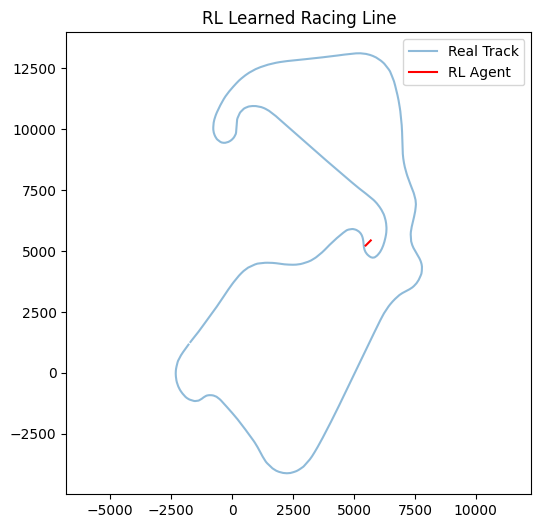

In [ ]:
path = np.array(path)

plt.figure(figsize=(6,6))

plt.plot(df['X'], df['Y'], label='Real Track', alpha=0.5)
plt.plot(path[:,0], path[:,1], label='RL Agent', color='red')

plt.legend()
plt.axis('equal')
plt.title("RL Learned Racing Line")
plt.show()

RL end

1st lstm

In [ ]:
# # start with first sequence
# current_seq = X_seq[0]

# predicted_path = []

# # start point
# x_curr, y_curr = y_seq[0]

# for _ in range(500):

#     # predict next point
#     pred = model.predict(current_seq.reshape(1, 20, -1), verbose=0)
#     x_next, y_next = pred[0]

#     predicted_path.append([x_next, y_next])

#     # --------------------------------
#     # rebuild next input features
#     # --------------------------------

#     # progress increases
#     progress = len(predicted_path) / 500

#     # approximate speed (reuse real trend)
#     speed_val = np.interp(progress, df['progress'], df['Speed'])

#     # corner strength
#     corner_strength = 1 - (speed_val / df['Speed'].max())

#     # IMPORTANT: use SAME features as training
#     new_input = [
#         progress,
#         speed_val,
#         corner_strength,
#         0   # placeholder if 4th feature exists
#     ]

#     # reshape
#     new_input = np.array(new_input)

#     # update sequence
#     current_seq = np.vstack([current_seq[1:], new_input])

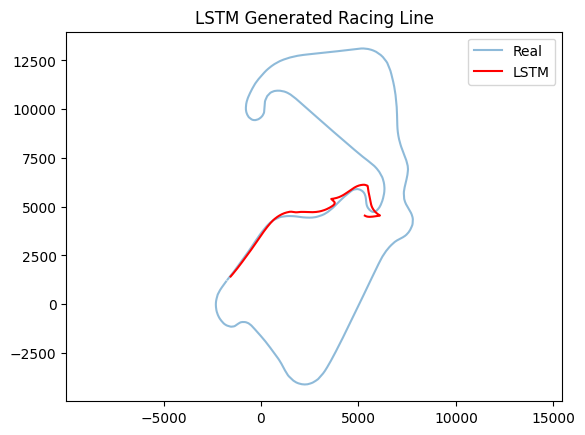

In [ ]:
# predicted_path = np.array(predicted_path)

# plt.plot(df['X'], df['Y'], label='Real', alpha=0.5)
# plt.plot(predicted_path[:,0], predicted_path[:,1], label='LSTM', color='red')

# plt.legend()
# plt.axis('equal')
# plt.title("LSTM Generated Racing Line")
# plt.show()
plt.plot(df['X'], df['Y'], label='Real', alpha=0.5)
plt.plot(predicted_path[:,0], predicted_path[:,1], label='LSTM', color='red')

plt.legend()
plt.axis('equal')
plt.title("LSTM Generated Racing Line")
plt.show()

this is PREVIOUS LSTM that refuse to remove

In [ ]:
# df = pd.concat(all_data).reset_index(drop=True)

# print(df.head())
# print("Total samples:", len(df))

In [ ]:
# plt.figure(figsize=(10,8))

# for drv in df['Driver'].unique():
#     d = df[df['Driver'] == drv]
#     plt.plot(d['X'], d['Y'], label=drv, alpha=0.6)

# plt.legend()
# plt.axis('equal')
# plt.title("Multi-Driver Racing Lines")
# plt.show()

In [ ]:
# df['dx'] = df['X'].diff()
# df['dy'] = df['Y'].diff()

# df = df.dropna().reset_index(drop=True)

# # next position
# df['X_next'] = df['X'].shift(-1)
# df['Y_next'] = df['Y'].shift(-1)

# df = df.dropna().reset_index(drop=True)

In [ ]:
# from sklearn.model_selection import train_test_split

# features = ['X','Y','Speed','dx','dy']
# target = ['X_next','Y_next']

# X = df[features]
# y = df[target]

# X_train, X_test, y_train, y_test = train_test_split(
#     X, y, test_size=0.2, random_state=42
# )

In [ ]:
# from scipy.ndimage import label

# labels, num_features = label(low_speed_mask)

In [ ]:
# from sklearn.ensemble import RandomForestRegressor

# rf_model = RandomForestRegressor(n_estimators=100)
# rf_model.fit(X_train, y_train)

# y_pred = rf_model.predict(X_test)

In [ ]:
# from sklearn.metrics import mean_squared_error

# print("RF MSE:", mean_squared_error(y_test, y_pred))

In [ ]:
# apex_x = []
# apex_y = []

# for i in range(1, num_features + 1):
#     indices = np.where(labels == i)[0]

#     if len(indices) == 0:
#         continue

#     # find index of minimum speed in this corner
#     min_idx = indices[np.argmin(speed[indices])]

#     apex_x.append(x[min_idx])
#     apex_y.append(y[min_idx])

In [ ]:
# df = tel[['X','Y','Speed']].copy()

# # motion
# df['dx'] = df['X'].diff()
# df['dy'] = df['Y'].diff()

# # curvature
# df['ddx'] = df['dx'].diff()
# df['ddy'] = df['dy'].diff()
# df['curvature'] = np.sqrt(df['ddx']**2 + df['ddy']**2)

# # corner awareness
# df['corner_strength'] = 1 - (df['Speed'] / df['Speed'].max())
# # 4. Direction (theta)
# df['theta'] = np.arctan2(df['dy'], df['dx'])
# # 5. Progress (VERY IMPORTANT)
# dist = np.sqrt(df['dx']**2 + df['dy']**2)
# df['progress'] = dist.cumsum()
# df['progress'] = df['progress'] / df['progress'].max()
# # target
# df['X_next'] = df['X'].shift(-1)
# df['Y_next'] = df['Y'].shift(-1)
# # 7. Drop NaNs
# df = df.dropna().reset_index(drop=True)
# # 8. Apex labeling
# df['is_apex'] = 0

# for ax, ay in zip(apex_x, apex_y):
#     dist = np.sqrt((df['X'] - ax)**2 + (df['Y'] - ay)**2)
#     df.loc[dist < 50, 'is_apex'] = 1
# # 9. Features + Target
# features = [
#     'X','Y','Speed','dx','dy',
#     'curvature','corner_strength',
#     'is_apex','theta','progress'
# ]
# y_target = df[['X_next','Y_next']]

In [ ]:
# from sklearn.preprocessing import MinMaxScaler

# scaler_X = MinMaxScaler()
# scaler_y = MinMaxScaler()

# X_scaled = scaler_X.fit_transform(df[features])
# scaler_y.fit(df[['X_next', 'Y_next']])

In [ ]:
# sequence_length = 10

# X_seq = []
# y_seq = []

# for i in range(len(X_scaled) - sequence_length):
#     X_seq.append(X_scaled[i:i+sequence_length])
#     y_seq.append(y_scaled[i+sequence_length])

# X_seq = np.array(X_seq)
# y_seq = np.array(y_seq)

In [ ]:
# from sklearn.model_selection import train_test_split

# X_train, X_test, y_train, y_test = train_test_split(
#     X_seq, y_seq, test_size=0.2, random_state=42
# )

In [ ]:
# from tensorflow.keras.models import Sequential
# from tensorflow.keras.layers import LSTM, Dense
# from tensorflow.keras import Input


# model = Sequential([
#     Input(shape=(sequence_length, X_seq.shape[2])),
#     LSTM(64),
#     Dense(32, activation='relu'),
#     Dense(2)
# ])

# model.compile(optimizer='adam', loss='mse')

# history = model.fit(
#     X_train, y_train,
#     epochs=15,
#     batch_size=32,
#     validation_data=(X_test, y_test)
# )

In [ ]:
# current_seq = X_seq[0]

# predicted_path = []

# # start position
# x_curr = df['X'].iloc[0]
# y_curr = df['Y'].iloc[0]

# for step in range(500):

#     # 🔮 model prediction
#     pred = model.predict(current_seq.reshape(1, sequence_length, -1), verbose=0)

#     dx_pred, dy_pred = scaler_y.inverse_transform(pred)[0]

#     # ---------------------------------
#     # 🔥 FIX 1: normalize direction
#     # ---------------------------------
#     norm = np.sqrt(dx_pred**2 + dy_pred**2)
#     if norm > 0:
#         dx_pred /= norm
#         dy_pred /= norm

#     # ---------------------------------
#     # 🔥 FIX 2: clamp movement
#     # ---------------------------------
#     max_step = 1   # small step since we normalize
#     dx_pred = np.clip(dx_pred, -max_step, max_step)
#     dy_pred = np.clip(dy_pred, -max_step, max_step)

#     # ---------------------------------
#     # 🔥 FIX 3: controlled step size
#     # ---------------------------------
#     alpha = 20   # tune this (10–30 range works well)

#     x_curr += alpha * dx_pred
#     y_curr += alpha * dy_pred

#     predicted_path.append([x_curr, y_curr])

#     # ---------------------------------
#     # FEATURE BUILDING (match training)
#     # ---------------------------------

#     # direction
#     theta = np.arctan2(dy_pred, dx_pred)

#     # approximate speed progression
#     idx = min(len(df) - 1, step)
#     speed_val = df['Speed'].iloc[idx]

#     # curvature approximation
#     if len(predicted_path) > 2:
#         x1, y1 = predicted_path[-3]
#         x2, y2 = predicted_path[-2]
#         x3, y3 = predicted_path[-1]

#         curvature = abs((x2-x1)*(y3-y2) - (y2-y1)*(x3-x2))
#     else:
#         curvature = 0

#     # corner awareness
#     corner_strength = 1 - (speed_val / df['Speed'].max())

#     # progress
#     progress_val = step / len(df)

#     # apex detection
#     is_apex = 0
#     for ax, ay in zip(apex_x, apex_y):
#         if np.sqrt((x_curr - ax)**2 + (y_curr - ay)**2) < 100:
#             is_apex = 1
#             break

#     # ---------------------------------
#     # build next input (IMPORTANT ORDER)
#     # ---------------------------------
#     new_input = [
#         x_curr,
#         y_curr,
#         speed_val,
#         dx_pred,
#         dy_pred,
#         curvature,
#         corner_strength,
#         is_apex,
#         theta,
#         progress_val
#     ]

#     new_input_df = pd.DataFrame([new_input], columns=features)
#     new_input_scaled = scaler_X.transform(new_input_df)[0]

#     # update sequence
#     current_seq = np.vstack([current_seq[1:], new_input_scaled])


# # convert to array
# predicted_path = np.array(predicted_path)

In [ ]:
# plt.plot(df['X'], df['Y'], label='Real', alpha=0.5)
# plt.plot(predicted_path[:,0], predicted_path[:,1], label='AI', color='red')

# plt.legend()
# plt.axis('equal')
# plt.title("AI Generated Racing Line (Stable)")
# plt.show()

In [ ]:
# from scipy.spatial import cKDTree

# track_points = np.column_stack((df['X'], df['Y']))
# tree = cKDTree(track_points)

In [ ]:
# current_seq = X_seq[0]
# predicted_path = []

# x_curr = df['X'].iloc[0]
# y_curr = df['Y'].iloc[0]

# for _ in range(400):

#     pred = model.predict(current_seq.reshape(1, sequence_length, -1), verbose=0)

#     delta = scaler_y.inverse_transform(pred)[0]
#     dx_pred, dy_pred = delta

#     # update position
#     x_curr += dx_pred
#     y_curr += dy_pred

#     # ✅ SNAP + FORWARD (INSIDE LOOP)
#     dist, idx = tree.query([x_curr, y_curr])
#     idx = (idx + 3) % len(df)

#     x_curr = df['X'].iloc[idx]
#     y_curr = df['Y'].iloc[idx]

#     predicted_path.append([x_curr, y_curr])

#     new_input = np.array([
#         x_curr,
#         y_curr,
#         df['Speed'].iloc[idx],
#         dx_pred,
#         dy_pred
#     ])

#     new_input_scaled = scaler_X.transform([new_input])[0]

#     current_seq = np.vstack([current_seq[1:], new_input_scaled])

In [ ]:
# predicted_path = np.array(predicted_path)

# plt.figure(figsize=(10,8))
# plt.plot(df['X'], df['Y'], label='Real', alpha=0.5)
# plt.plot(predicted_path[:,0], predicted_path[:,1], label='AI', color='red')

# plt.legend()
# plt.axis('equal')
# plt.title("AI vs Real Racing Line")
# plt.show()